# Image Data Augmentation

Implemented Methods:
- Transforming Lightening (Brightness, Contrast, Hue, Saturation, Gamma)
- Intensities of RGB
- CROP (2%-3%)
- Left / Right Rotation (3-5 Degrees)
- ZOOM (2%-3%)
- Median Blur
- Random GAUSSIAN NOISE Addition

In [65]:
%pip install opencv-python pillow

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import shutil

from PIL import Image, ImageEnhance

import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# input images dir
input_original_images_dir = "/mnt/c/Users/1103/OneDrive - csu.edu.cn/SEEMAB_Official_work/image_datasets/Night Vision Fasteners png Enhanced DCE_model_11_23_2024[50] 20_images"

input_masked_images_dir = "/mnt/c/Users/1103/OneDrive - csu.edu.cn/SEEMAB_Official_work/image_datasets/Night Vision Fasteners png Enhanced DCE_model_11_23_2024[50] 20_masks"


augmented_original_images_dir = "/mnt/c/Users/1103/OneDrive - csu.edu.cn/SEEMAB_Official_work/image_datasets/Night Vision Fasteners png Enhanced DCE_model_11_23_2024[50] 20_images augmented"
augmented_mask_images_dir = "/mnt/c/Users/1103/OneDrive - csu.edu.cn/SEEMAB_Official_work/image_datasets/Night Vision Fasteners png Enhanced DCE_model_11_23_2024[50] 20_masks augmented"

In [2]:
def display_images(image_1, image_2 = None):
    # add a figure of 20 inch width and 14 inch height
    fig = plt.figure(figsize=(20, 14))

    rows = cols = 2

    # add picture 1 sub plot
    pos = 1
    fig.add_subplot(rows, cols, pos)
    plt.imshow(image_1)
    plt.axis('off')
    plt.title("image_1")


    if image_2:
        # add picture 2 sub plot
        pos = 2
        fig.add_subplot(rows, cols, pos)
        plt.imshow(image_2)
        plt.axis('off')
        plt.title("image_2")

    print("Content Displayed!")

## Methods Implementation

### Tune Brightness

In [2]:
def tune_brightness(input_img, factor):
    # tune brightness
    print(f"Brightness Factor:\t{factor}")
    filter = ImageEnhance.Brightness(input_img)
    new_img = filter.enhance(factor)
    return new_img

Brightness Factor:	0.85
Content Displayed!


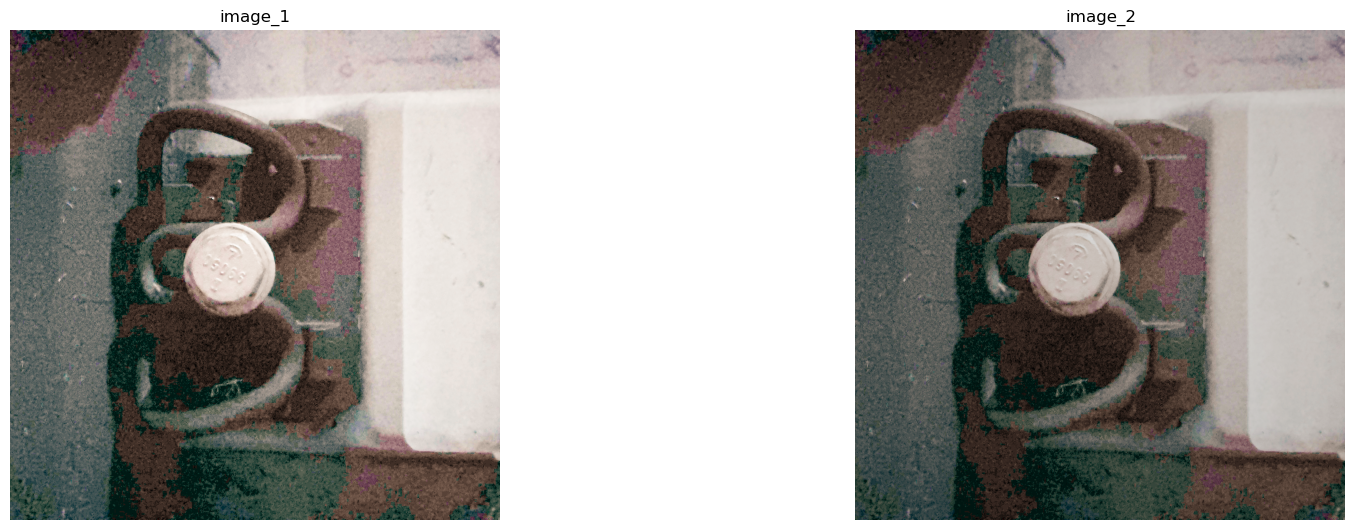

In [7]:
# Testing code
# brightness_range = list(np.round(np.arange(0.8, 1.21, 0.05), 2))
# # remove 1 for original image value
# brightness_range.remove(1)
# brightness_factor = np.random.choice(brightness_range)

# new_img = tune_brightness(original_img, brightness_factor)

# display_images(original_img, new_img)

### Tune Contrast

In [3]:
def tune_contrast(input_img, factor):
    # tune contrast
    print(f"Contrast Factor:\t{factor}")
    filter = ImageEnhance.Contrast(input_img)
    new_img = filter.enhance(factor)
    return new_img

Contrast Factor:	1.25
Content Displayed!


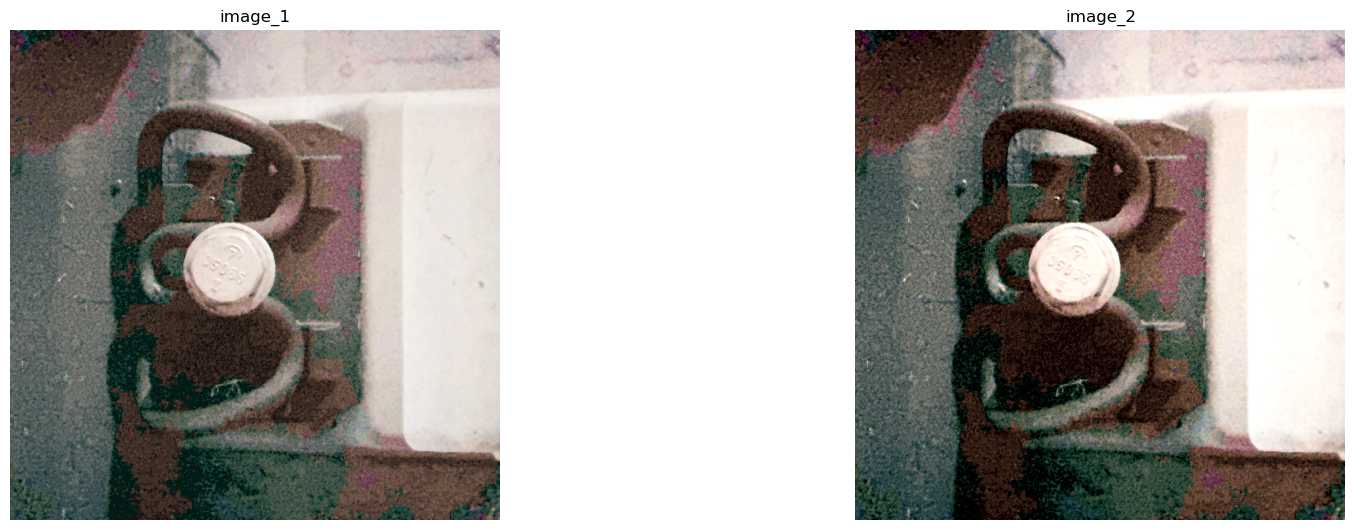

In [9]:
# Testing code
# contrast_range = list(np.round(np.arange(0.8, 1.51, 0.05), 2))
# # remove 1 for original image value
# contrast_range.remove(1)
# contrast_factor = np.random.choice(contrast_range)

# new_img = tune_contrast(original_img, contrast_factor)

# display_images(original_img, new_img)

### Tune Color / Saturation

In [4]:
def tune_color(input_img, factor):
    # tune color
    print(f"Color Factor:\t{factor}")
    filter = ImageEnhance.Color(input_img)
    new_img = filter.enhance(factor)
    return new_img

In [19]:
# Testing code
# color_range = list(np.round(np.arange(0.8, 1.51, 0.05), 2))
# # remove 1 for original image value
# color_range.remove(1)
# color_factor = np.random.choice(color_range)

# new_img = tune_color(original_img, color_factor)

# display_images(original_img, new_img)

### Add Gaussian Blur

In [6]:
# we have used cv2.randn() function to generate a Gaussian noise whose distribution is defined by a mean value, 
# and standard deviation value. We then add this noise to the image, and save the noisy image.

import cv2
import numpy as np

def add_gaussian_noise(input_image):
    # Load the image
    new_img_rgb = np.array(input_image.convert('RGB'))
    new_img_bgr = cv2.cvtColor(new_img_rgb, cv2.COLOR_RGB2BGR)

    # Generate random Gaussian noise
    mean = 0
    stddev = 180
    gaussian_noise = np.zeros(new_img_bgr.shape, np.uint8)
    cv2.randn(gaussian_noise, mean, stddev)

    # Add noise to image
    noisy_new_img = cv2.add(new_img_bgr, gaussian_noise)

    # converted from BGR to RGB
    color_converted = cv2.cvtColor(noisy_new_img, cv2.COLOR_BGR2RGB)

    # Displaying the converted image
    pil_image = Image.fromarray(color_converted)

    return pil_image

In [ ]:
# Testing code
# display_images(original_img, add_gaussian_noise(new_img))

## Augment Function

In [7]:
import cv2
import os
import shutil
import numpy as np
from PIL import Image, ImageEnhance

def add_gaussian_noise(input_image):
    # Load the image
    new_img_rgb = np.array(input_image.convert('RGB'))
    new_img_bgr = cv2.cvtColor(new_img_rgb, cv2.COLOR_RGB2BGR)

    # Generate random Gaussian noise
    mean = 0
    stddev = 180
    gaussian_noise = np.zeros(new_img_bgr.shape, np.uint8)
    cv2.randn(gaussian_noise, mean, stddev)

    # Add noise to image
    noisy_new_img = cv2.add(new_img_bgr, gaussian_noise)

    # converted from BGR to RGB
    color_converted = cv2.cvtColor(noisy_new_img, cv2.COLOR_BGR2RGB)

    # Displaying the converted image
    pil_image = Image.fromarray(color_converted)

    return pil_image

def tune_color(input_img, factor):
    # tune color
    print(f"Color Factor:\t{factor}")
    filter = ImageEnhance.Color(input_img)
    new_img = filter.enhance(factor)
    return new_img

def tune_contrast(input_img, factor):
    # tune contrast
    print(f"Contrast Factor:\t{factor}")
    filter = ImageEnhance.Contrast(input_img)
    new_img = filter.enhance(factor)
    return new_img

def tune_brightness(input_img, factor):
    # tune brightness
    print(f"Brightness Factor:\t{factor}")
    filter = ImageEnhance.Brightness(input_img)
    new_img = filter.enhance(factor)
    return new_img

def augment_image(original_image):
    
    # read original img
    original_img = Image.open(original_image)
    
    color_range = list(np.round(np.arange(0.8, 1.51, 0.05), 2))
    # remove 1 for original image value
    color_range.remove(1)
    color_factor = np.random.choice(color_range)
    new_img = tune_color(original_img, color_factor)
    
    contrast_range = list(np.round(np.arange(0.8, 1.51, 0.05), 2))
    # remove 1 for original image value
    contrast_range.remove(1)
    contrast_factor = np.random.choice(contrast_range)

    new_img = tune_contrast(new_img, contrast_factor)

    brightness_range = list(np.round(np.arange(0.8, 1.21, 0.05), 2))
    # remove 1 for original image value
    brightness_range.remove(1)
    brightness_factor = np.random.choice(brightness_range)

    new_img = tune_brightness(new_img, brightness_factor)
    
    new_img = add_gaussian_noise(new_img)
    
    return new_img

In [20]:
def generate_augmented_images(original_image, masked_image, augmented_original_images_dir, augmented_mask_images_dir, size:int=3):
    os.makedirs(augmented_original_images_dir, exist_ok=True)
    os.makedirs(augmented_mask_images_dir, exist_ok=True)

    new_original_image = os.path.join(augmented_original_images_dir, os.path.basename(original_image))
    shutil.copy(original_image, new_original_image)    

    new_mask_image = os.path.join(augmented_mask_images_dir, os.path.basename(masked_image))
    shutil.copy(masked_image, new_mask_image)

    for i in range(1, size + 1):
        # generate augmented_image
        augmented_image = augment_image(original_image=original_image)
        # make path
        new_augmented_image = os.path.basename(original_image).split(".")[0] + f"_s{i}." + os.path.basename(original_image).split(".")[1]
        new_augmented_image = os.path.join(augmented_original_images_dir, new_augmented_image)
        # save augmented image
        augmented_image.save(new_augmented_image)
        
        # make a copy of masked image
        new_masked_image = os.path.basename(masked_image).split(".")[0] + f"_s{i}." + os.path.basename(masked_image).split(".")[1]
        new_masked_image = os.path.join(augmented_mask_images_dir, new_masked_image)
        shutil.copy(masked_image, new_masked_image)

In [24]:
# list images
original_images = os.listdir(input_original_images_dir)

for original_image in original_images:
    if not original_image.endswith(".png"):
        continue
    masked_image = os.path.join(input_masked_images_dir , original_image.split(".")[0]
                                + "." + original_image.split(".")[1])
    original_image = os.path.join(input_original_images_dir, original_image)
    generate_augmented_images(original_image=original_image, masked_image=masked_image, augmented_original_images_dir=augmented_original_images_dir, augmented_mask_images_dir=augmented_mask_images_dir, size=5)
    

Color Factor:	1.15
Contrast Factor:	0.95
Brightness Factor:	0.85
Color Factor:	0.9
Contrast Factor:	1.1
Brightness Factor:	0.85
Color Factor:	1.2
Contrast Factor:	1.45
Brightness Factor:	0.9
Color Factor:	0.95
Contrast Factor:	1.05
Brightness Factor:	1.05
Color Factor:	1.2
Contrast Factor:	1.5
Brightness Factor:	0.9
Color Factor:	1.05
Contrast Factor:	0.8
Brightness Factor:	1.15
Color Factor:	1.35
Contrast Factor:	1.2
Brightness Factor:	0.85
Color Factor:	0.9
Contrast Factor:	1.35
Brightness Factor:	0.9
Color Factor:	1.4
Contrast Factor:	1.3
Brightness Factor:	0.85
Color Factor:	1.3
Contrast Factor:	1.1
Brightness Factor:	0.9
Color Factor:	0.95
Contrast Factor:	0.85
Brightness Factor:	0.85
Color Factor:	0.8
Contrast Factor:	1.5
Brightness Factor:	1.2
Color Factor:	1.05
Contrast Factor:	0.85
Brightness Factor:	0.95
Color Factor:	0.85
Contrast Factor:	1.3
Brightness Factor:	0.95
Color Factor:	0.95
Contrast Factor:	0.9
Brightness Factor:	1.2
Color Factor:	0.9
Contrast Factor:	1.25
Brightn

### Rotate Image (Pending)

Angle:	2.0


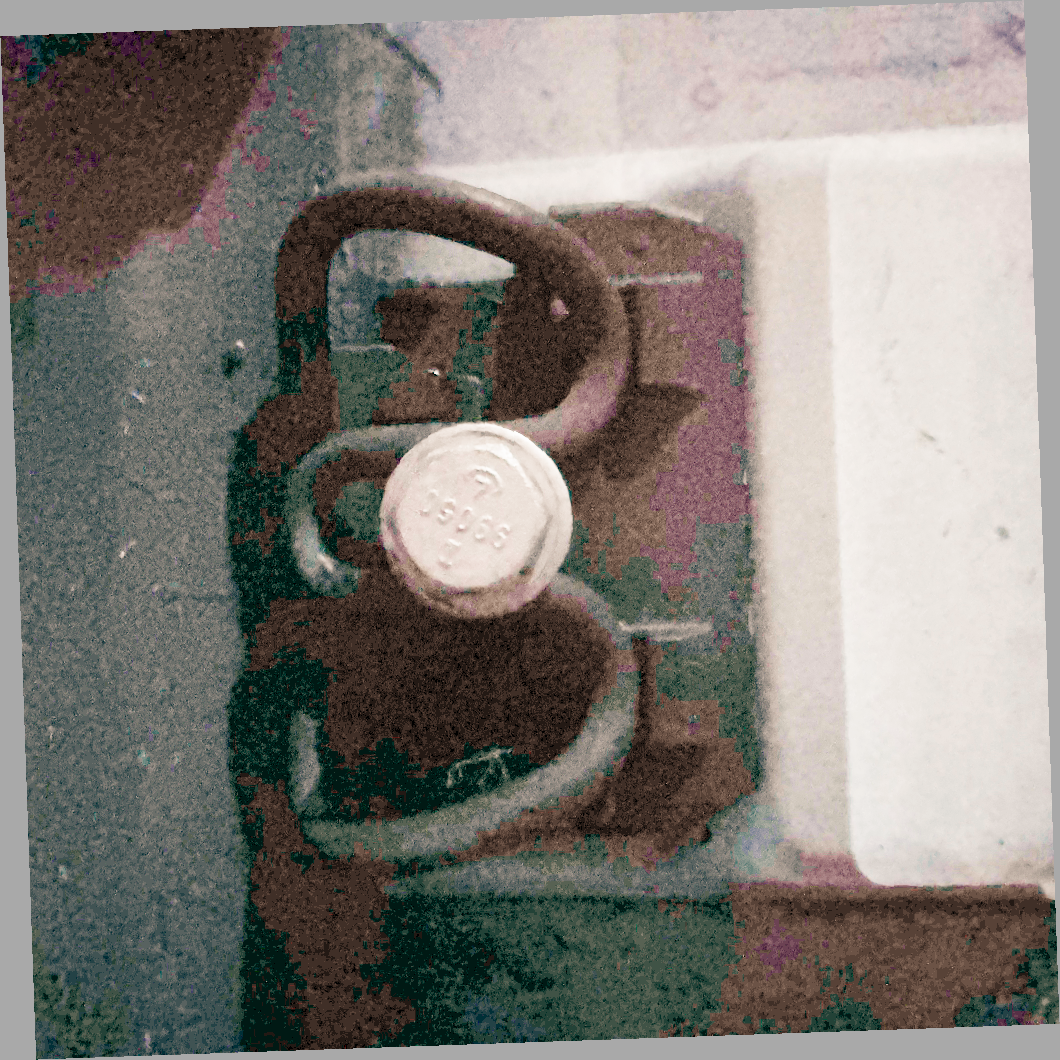

In [199]:
def rotate_image(Original_Image, angle):
    # tune color
    print(f"Angle:\t{angle}")
    # Rotate Image By angle Degree
    rotated_image = Original_Image.rotate(angle, expand=True, fillcolor=(169, 169, 169))
    return rotated_image

# rotate_range = list(np.round(np.arange(-3, 3, 0.5), 2))

# # remove 0 for original image value
# rotate_range.remove(0)

# rotate_factor = np.random.choice(rotate_range)

# rotate_image(original_img, - rotate_factor)

In [206]:
def scale_image_size(source_image_file_path, new_img_width, new_img_height, target_image_file_path):
    
    # open the source image object.
    source_img_obj = Image.open(source_image_file_path)
    
    # scale the image to the new size, it will return a new Image object.
    scaled_img = source_img_obj.resize((new_img_width, new_img_height))
    
    # save the scaled image to a new file.
    # scaled_img.save(target_image_file_path)

    # get the source image size.
    source_image_size = source_img_obj.size
        
    # get the scaled image size.
    scaled_img_size = scaled_img.size

    # print the source image size.
    print("The source image size is :", source_image_size)
    
    # print the scaled image size.
    print("The scaled image size is :", scaled_img_size)

    # scale part of the source image.
    scaled_special_area_img = source_img_obj.resize((new_img_width,new_img_height),resample=Image.LANCZOS,box=(10,10,200,300))
    
    # display the scaled part image.
    scaled_special_area_img.show()

In [207]:
source_image_file_path = 'noisy_img.jpg'

target_image_file_path = 'noisy_img.jpg'

new_img_width = 800

new_img_height = 600

scale_image_size(source_image_file_path, new_img_width, new_img_height, target_image_file_path)

The source image size is : (800, 600)
The scaled image size is : (800, 600)


## The End